ADDING ALL THE DEPENDENCIES

In [38]:
from src.pull import pull_all_tables
import pandas as pd
import sklearn

THIS IS PULLING ALL THE TABLES AND CHECKING IF THE DATA SENT IS EQUAL TO THE DATA RECEIVED

In [39]:
dataframes= pull_all_tables()
for name, df in dataframes.items():
    print(f"Table: {name}, Shape: {df.shape}")

Table: circuits, Shape: (76, 6)
Table: constructors, Shape: (168, 3)
Table: constructor_standings, Shape: (111, 6)
Table: drivers, Shape: (616, 5)
Table: driver_standings, Shape: (244, 6)
Table: qualifying, Shape: (1100, 9)
Table: races, Shape: (233, 6)
Table: results, Shape: (1100, 11)


WE PULL ALL THE DATA FRAMES AND THEN VERIFY IF IT ALL WORKS

In [40]:
circuits= dataframes['circuits']
circuits.head()

,circuit_id,name,lat,long,locality,country
0,silverstone,Silverstone Circuit,52.0786,-1.01694,Silverstone,UK
1,monaco,Circuit de Monaco,43.7347,7.42056,Monte-Carlo,Monaco
2,indianapolis,Indianapolis Motor Speedway,39.7950,-86.23470,Indianapolis,USA
3,bremgarten,Circuit Bremgarten,46.9589,7.40194,Bern,Switzerland
4,spa,Circuit de Spa-Francorchamps,50.4372,5.97139,Spa,Belgium


In [41]:
constructors= dataframes['constructors']
constructors.head()

,constructor_id,name,nationality
0,sherman,Sherman,American
1,schroeder,Schroeder,American
2,kuzma,Kuzma,American
3,pawl,Pawl,American
4,hall,Hall,American


In [42]:
constuctor_standings= dataframes['constructor_standings']
constuctor_standings.head()
constuctor_standings.info()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   season          111 non-null    int64  
 1   round           111 non-null    int64  
 2   constructor_id  111 non-null    str    
 3   position        111 non-null    int64  
 4   points          111 non-null    float64
 5   wins            111 non-null    int64  
dtypes: float64(1), int64(4), str(1)
memory usage: 5.3 KB


In [43]:
drivers= dataframes['drivers']
drivers.head()

,driver_id,given_name,family_name,nationality,dob
0,mantovani,Sergio,Mantovani,Italian,1929-05-22
1,swaters,Jacques,Swaters,American,1926-10-30
2,kling,Karl,Kling,German,1910-09-16
3,herrmann,Hans,Herrmann,German,1928-02-23
4,bucci,Clemar,Bucci,Argentine,1920-09-04


In [44]:
driver_standings= dataframes['driver_standings']
driver_standings.head()

,season,round,driver_id,position,points,wins
0,2015,19,rosberg,2.0,322.0,6
1,2017,20,vettel,2.0,317.0,5
2,2017,20,bottas,3.0,305.0,3
3,2017,20,raikkonen,4.0,205.0,0
4,2017,20,ricciardo,5.0,200.0,1


In [45]:
qualifying= dataframes['qualifying']
qualifying.head()

,race_id,driver_id,constructor_id,position,q1,q2,q3,season,round
0,2015_6,vettel,ferrari,3,1:17.502,1:16.181,1:15.849,2015,6
1,2015_6,ricciardo,red_bull,4,1:17.254,1:16.706,1:16.041,2015,6
2,2016_1,hamilton,mercedes,1,1:25.351,1:24.605,1:23.837,2016,1
3,2016_1,rosberg,mercedes,2,1:26.934,1:24.796,1:24.197,2016,1
4,2016_1,vettel,ferrari,3,1:26.945,1:25.257,1:24.675,2016,1


In [46]:
races= dataframes['races']
races.info()

<class 'pandas.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   race_id     233 non-null    str  
 1   season      233 non-null    int64
 2   round       233 non-null    int64
 3   race_name   233 non-null    str  
 4   date        233 non-null    str  
 5   circuit_id  233 non-null    str  
dtypes: int64(2), str(4)
memory usage: 11.1 KB


In [47]:
results= dataframes['results']
results.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,season,round
0,2015_5,raikkonen,ferrari,7,5,5,10,66,Finished,2015,5
1,2015_5,massa,williams,9,6,6,8,66,Finished,2015,5
2,2015_5,ricciardo,red_bull,10,7,7,6,65,+1 Lap,2015,5
3,2015_5,grosjean,lotus_f1,11,8,8,4,65,+1 Lap,2015,5
4,2015_5,sainz,toro_rosso,5,9,9,2,65,+1 Lap,2015,5


In [48]:
results=results.sort_values(['driver_id', 'season', 'round'], inplace=False)
results.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,season,round
332,2019_1,albon,toro_rosso,13,14,14,0,57,+1 Lap,2019,1
347,2019_2,albon,toro_rosso,12,9,9,2,57,Finished,2019,2
368,2019_3,albon,toro_rosso,0,10,10,1,55,+1 Lap,2019,3
389,2019_4,albon,toro_rosso,11,11,11,0,50,+1 Lap,2019,4
409,2019_5,albon,toro_rosso,11,11,11,0,66,Finished,2019,5


ADDED 2 MORE VARIABLES

In [49]:
results['avg_last_5']= (results.groupby('driver_id')['points'].transform(lambda x:x.shift(1).rolling(5, min_periods=1).mean()))

# Define DNF keywords
dnf_keywords = [
    'retired', 'accident', 'collision', 'disqualified',
    'engine', 'gearbox', 'hydraulics', 'suspension', 'brakes',
    'electrical', 'electronics', 'power', 'ers', 'turbo',
    'transmission', 'fuel', 'oil', 'overheating', 'water',
    'driveshaft', 'cooling', 'mechanical', 'wheel', 'puncture',
    'spun', 'withdrew', 'damage', 'vibrations', 'puncture'
]

# Create a regex pattern to match any of the DNF keywords
dnf_pattern = '|'.join(dnf_keywords)

# Create a new column 'dnf' that is 1 if 'status' contains any DNF keyword, otherwise 0
results['dnf'] = results['status'].str.contains(dnf_pattern, case=False, na=False).astype(int)

# Create a new column 'dnf_rate_5' that calculates the rolling average of 'dnf' over the last 5 races
results['dnf_rate_5'] = results.groupby('driver_id')['dnf'].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())

results.groupby('constructor_id').apply(lambda x: x[x['season'] == 2019]).head(10)


race_id   driver_id  grid position  position_order  points  \
constructor_id                                                                  
alfa           333  2019_1  giovinazzi    14       15              15       0   
               349  2019_2  giovinazzi    16       11              11       0   
               373  2019_3  giovinazzi    19       15              15       0   
               390  2019_4  giovinazzi    17       12              12       0   
               414  2019_5  giovinazzi    18       16              16       0   
               326  2019_1   raikkonen     9        8               8       4   
               345  2019_2   raikkonen     8        7               7       6   
               367  2019_3   raikkonen    13        9               9       2   
               388  2019_4   raikkonen     0       10              10       1   
               412  2019_5   raikkonen    14       14              14       0   

                    laps    status  season  round  avg_last_5  dnf  dnf_rate_5  
constructor_id                                                                  
alfa           333    57    +1 Lap    2019      1         0.0    0    0.500000  
               349    57  Finished    2019      2         0.0    0    0.333333  
               373    55    +1 Lap    2019      3         0.0    0    0.250000  
               390    50    +1 Lap    2019      4         0.0    0    0.200000  
               414    66  Finished    2019      5         0.0    0    0.200000  
               326    57    +1 Lap    2019      1         9.6    0    0.400000  
               345    57  Finished    2019      2         7.4    0    0.400000  
               367    55    +1 Lap    2019      3         8.6    0    0.200000  
               388    50    +1 Lap    2019      4         6.0    0    0.200000  
               412    66  Finished    2019      5         2.6    0    0.200000

SAMPLE TEST JUST TO CHECK IF THIS WORKS PROPERLY

In [50]:
# Create a small test DataFrame to verify the logic
test_data = pd.DataFrame({
    'driver_id': [1, 1, 1, 1, 1, 1, 1],
    'season': [2023]*7,
    'round': [1, 2, 3, 4, 5, 6, 7],
    'status': ['Finished', 'Engine', 'Finished', 'Accident', 'Finished', 'Gearbox', 'Finished'],
    'points': [10, 0, 8, 0, 6, 0, 4]
})

# Apply your logic to this test data
test_data['dnf'] = test_data['status'].str.contains(dnf_pattern, case=False, na=False).astype(int)
test_data['dnf_rate_5'] = test_data.groupby('driver_id')['dnf'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

test_data['avg_last_5']= (test_data.groupby('driver_id')['points'].transform(lambda x:x.shift(1).rolling(5, min_periods=1).mean()))


print("Test data results:")
print(test_data[['round', 'points', 'status', 'dnf', 'dnf_rate_5', 'avg_last_5']])
# Verify manually: 
# Round 6 should have rate = (0+1+0+1+0)/5 = 2/5 = 0.4 (looking at rounds 1-5)

Test data results:
   round  points    status  dnf  dnf_rate_5  avg_last_5
0      1      10  Finished    0         NaN         NaN
1      2       0    Engine    1    0.000000        10.0
2      3       8  Finished    0    0.500000         5.0
3      4       0  Accident    1    0.333333         6.0
4      5       6  Finished    0    0.500000         4.5
5      6       0   Gearbox    1    0.400000         4.8
6      7       4  Finished    0    0.600000         2.8


Join Qualifying To Results (MAINLY BECAUSE OF STUFF LIKE TIME PENALTIES)

In [51]:
qualifying_merge= qualifying[['race_id', 'driver_id', 'position']].rename(columns={'position': 'qualifying_position'})
results_merged= results.merge(qualifying_merge, on=['race_id', 'driver_id'], how='left')
results_merged.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,season,round,avg_last_5,dnf,dnf_rate_5,qualifying_position
0,2019_1,albon,toro_rosso,13,14,14,0,57,+1 Lap,2019,1,NaN,0,NaN,13.0
1,2019_2,albon,toro_rosso,12,9,9,2,57,Finished,2019,2,0.00,0,0.0,12.0
2,2019_3,albon,toro_rosso,0,10,10,1,55,+1 Lap,2019,3,1.00,0,0.0,NaN
3,2019_4,albon,toro_rosso,11,11,11,0,50,+1 Lap,2019,4,1.00,0,0.0,12.0
4,2019_5,albon,toro_rosso,11,11,11,0,66,Finished,2019,5,0.75,0,0.0,12.0


MERGED DRIVER STANDINGS

In [52]:
driver_standings_merge= driver_standings[['season', 'round', 'driver_id', 'position', 'points']].rename(columns={'position': 'driver_championship_pos','points':   'driver_championship_pts'})
driver_standings_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   season                   244 non-null    int64  
 1   round                    244 non-null    int64  
 2   driver_id                244 non-null    str    
 3   driver_championship_pos  241 non-null    float64
 4   driver_championship_pts  244 non-null    float64
dtypes: float64(2), int64(2), str(1)
memory usage: 9.7 KB


In [53]:
results_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   race_id              1100 non-null   str    
 1   driver_id            1100 non-null   str    
 2   constructor_id       1100 non-null   str    
 3   grid                 1100 non-null   int64  
 4   position             1100 non-null   str    
 5   position_order       1100 non-null   int64  
 6   points               1100 non-null   int64  
 7   laps                 1100 non-null   int64  
 8   status               1100 non-null   str    
 9   season               1100 non-null   int64  
 10  round                1100 non-null   int64  
 11  avg_last_5           1049 non-null   float64
 12  dnf                  1100 non-null   int64  
 13  dnf_rate_5           1049 non-null   float64
 14  qualifying_position  1090 non-null   float64
dtypes: float64(3), int64(7), str(5)
memory usage: 129

In [54]:
# Get the final driver standings for each season (last round per driver)
final_driver_standings = driver_standings_merge.loc[driver_standings_merge.groupby(['season', 'driver_id'])['round'].idxmax()].copy()

# Select relevant columns and rename for clarity
final_driver_standings = final_driver_standings[['season', 'driver_id', 'driver_championship_pos', 'driver_championship_pts']].rename(
    columns={
        'driver_championship_pos': 'final_driver_championship_pos',
        'driver_championship_pts': 'final_driver_championship_pts'
    }
)

final_driver_standings.head()

,season,driver_id,final_driver_championship_pos,final_driver_championship_pts
114,2015,alonso,17.0,11.0
172,2015,bottas,5.0,136.0
183,2015,button,16.0,16.0
115,2015,ericsson,18.0,9.0
178,2015,grosjean,11.0,51.0


In [55]:
# Merge into results_merged on season and driver_id
results_merged = results_merged.merge(final_driver_standings, on=['season', 'driver_id'], how='left')
results_merged.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,status,season,round,avg_last_5,dnf,dnf_rate_5,qualifying_position,final_driver_championship_pos,final_driver_championship_pts
0,2019_1,albon,toro_rosso,13,14,14,0,57,+1 Lap,2019,1,NaN,0,NaN,13.0,8.0,92.0
1,2019_2,albon,toro_rosso,12,9,9,2,57,Finished,2019,2,0.00,0,0.0,12.0,8.0,92.0
2,2019_3,albon,toro_rosso,0,10,10,1,55,+1 Lap,2019,3,1.00,0,0.0,NaN,8.0,92.0
3,2019_4,albon,toro_rosso,11,11,11,0,50,+1 Lap,2019,4,1.00,0,0.0,12.0,8.0,92.0
4,2019_5,albon,toro_rosso,11,11,11,0,66,Finished,2019,5,0.75,0,0.0,12.0,8.0,92.0


MERGED CONSTRUCTORS

In [56]:
# Now do the same for constructor standings
constructor_standings_merge = constuctor_standings[['season', 'round', 'constructor_id', 'position', 'points']].rename(
    columns={'position': 'constructor_championship_pos', 'points': 'constructor_championship_pts'}
)

# Get the final constructor standings for each season (last round per constructor)
final_constructor_standings = constructor_standings_merge.loc[constructor_standings_merge.groupby(['season', 'constructor_id'])['round'].idxmax()].copy()

# Select relevant columns and rename for clarity
final_constructor_standings = final_constructor_standings[['season', 'constructor_id', 'constructor_championship_pos', 'constructor_championship_pts']].rename(
    columns={
        'constructor_championship_pos': 'final_constructor_championship_pos',
        'constructor_championship_pts': 'final_constructor_championship_pts'
    }
)

# Merge into results_merged on season and constructor_id
results_merged = results_merged.merge(final_constructor_standings, on=['season', 'constructor_id'], how='left')

# Check for nulls in the new columns
null_constructor = results_merged[results_merged['final_constructor_championship_pts'].isnull()]
print(f"Number of rows with null final_constructor_championship_pts: {len(null_constructor)}")

results_merged.info()

Number of rows with null final_constructor_championship_pts: 0
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   race_id                             1100 non-null   str    
 1   driver_id                           1100 non-null   str    
 2   constructor_id                      1100 non-null   str    
 3   grid                                1100 non-null   int64  
 4   position                            1100 non-null   str    
 5   position_order                      1100 non-null   int64  
 6   points                              1100 non-null   int64  
 7   laps                                1100 non-null   int64  
 8   status                              1100 non-null   str    
 9   season                              1100 non-null   int64  
 10  round                               1100 non-null   int6

In [57]:
results_merged= results_merged.copy()
results_merged= results_merged.merge(races[['race_id', 'circuit_id']], on='race_id', how='left')
results_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   race_id                             1100 non-null   str    
 1   driver_id                           1100 non-null   str    
 2   constructor_id                      1100 non-null   str    
 3   grid                                1100 non-null   int64  
 4   position                            1100 non-null   str    
 5   position_order                      1100 non-null   int64  
 6   points                              1100 non-null   int64  
 7   laps                                1100 non-null   int64  
 8   status                              1100 non-null   str    
 9   season                              1100 non-null   int64  
 10  round                               1100 non-null   int64  
 11  avg_last_5                          1049 non-null   fl

Writing some more data analytics to view the relations

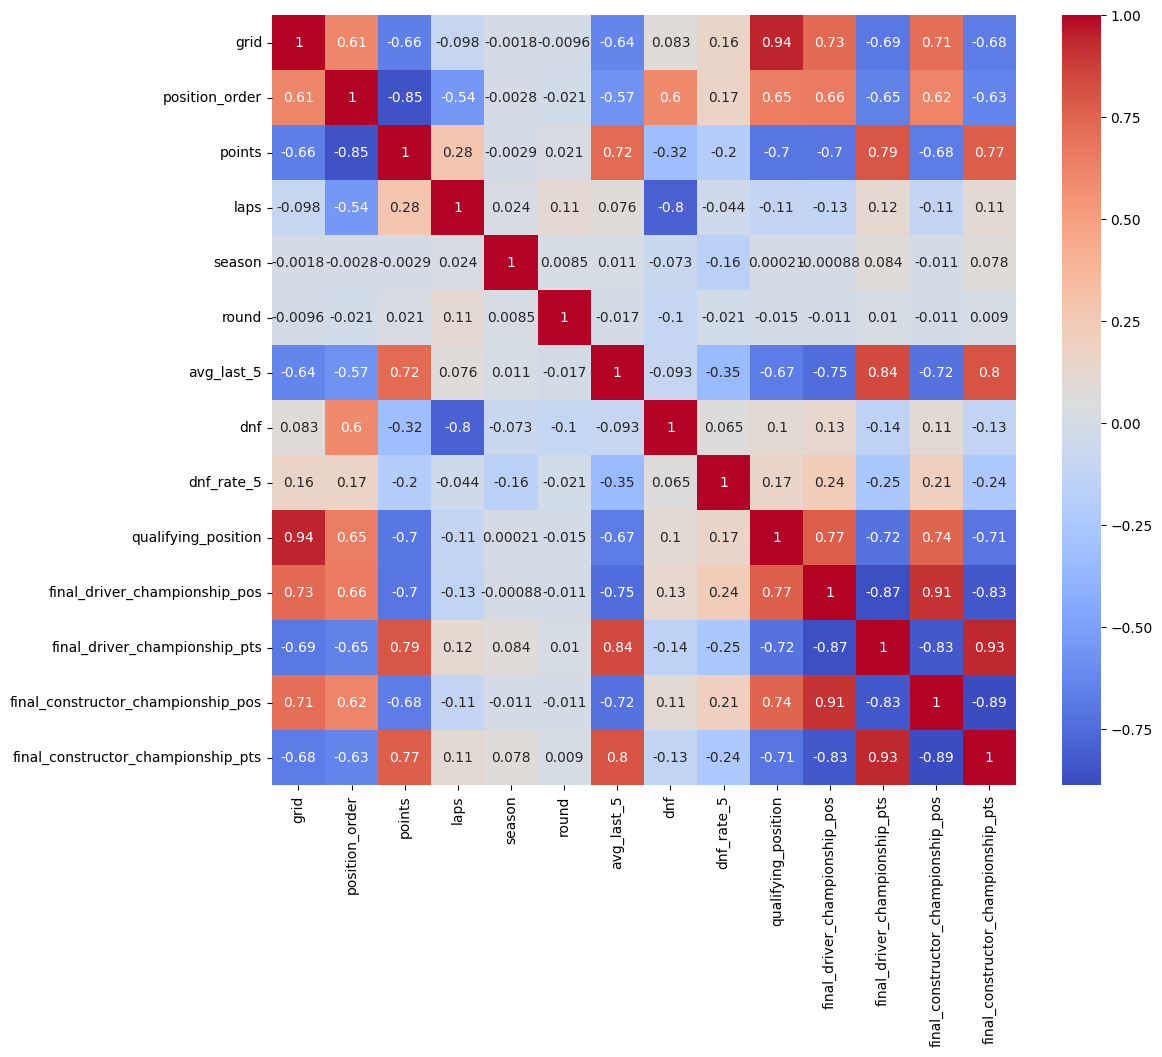

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

corr= results_merged.corr(numeric_only=True)

#Heatmap of correlations to see similar variables and potential multicollinearity issues
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

Encode All String Values to pass through the ML models

In [59]:
ml_data=results_merged.drop(columns=['status'])
ml_data.head()

,race_id,driver_id,constructor_id,grid,position,position_order,points,laps,season,round,avg_last_5,dnf,dnf_rate_5,qualifying_position,final_driver_championship_pos,final_driver_championship_pts,final_constructor_championship_pos,final_constructor_championship_pts,circuit_id
0,2019_1,albon,toro_rosso,13,14,14,0,57,2019,1,NaN,0,NaN,13.0,8.0,92.0,6,85.0,albert_park
1,2019_2,albon,toro_rosso,12,9,9,2,57,2019,2,0.00,0,0.0,12.0,8.0,92.0,6,85.0,bahrain
2,2019_3,albon,toro_rosso,0,10,10,1,55,2019,3,1.00,0,0.0,NaN,8.0,92.0,6,85.0,shanghai
3,2019_4,albon,toro_rosso,11,11,11,0,50,2019,4,1.00,0,0.0,12.0,8.0,92.0,6,85.0,baku
4,2019_5,albon,toro_rosso,11,11,11,0,66,2019,5,0.75,0,0.0,12.0,8.0,92.0,6,85.0,catalunya


In [60]:
from sklearn.preprocessing import LabelEncoder

cols= ['race_id', 'driver_id', 'constructor_id', 'circuit_id']
ml_data=ml_data.copy()  # Create a copy to avoid SettingWithCopyWarning
encoders={}

for col in cols:
    le= LabelEncoder()
    ml_data[col] = le.fit_transform(ml_data[col].astype(str))
    encoders[col] = le  # Store the encoder for potential invers"e transformation later
    print(f"  Encoded '{col}' — {len(le.classes_)} unique values")

  Encoded 'race_id' — 57 unique values
  Encoded 'driver_id' — 51 unique values
  Encoded 'constructor_id' — 18 unique values
  Encoded 'circuit_id' — 16 unique values


In [61]:
ml_data['position'].unique()

<StringArray>
['14',  '9', '10', '11', '13',  '4',  '5',  '8',  'R', '12', '15',  '7',  '6',
  'W', '17',  '3', '19', '18',  '1',  '2', '20', '16',  'D', '21', '22']
Length: 25, dtype: str

In [62]:
final_dataset= ml_data.drop(columns=['position'])
final_dataset.head()

,race_id,driver_id,constructor_id,grid,position_order,points,laps,season,round,avg_last_5,dnf,dnf_rate_5,qualifying_position,final_driver_championship_pos,final_driver_championship_pts,final_constructor_championship_pos,final_constructor_championship_pts,circuit_id
0,21,0,16,13,14,0,57,2019,1,NaN,0,NaN,13.0,8.0,92.0,6,85.0,0
1,22,0,16,12,9,2,57,2019,2,0.00,0,0.0,12.0,8.0,92.0,6,85.0,1
2,23,0,16,0,10,1,55,2019,3,1.00,0,0.0,NaN,8.0,92.0,6,85.0,12
3,24,0,16,11,11,0,50,2019,4,1.00,0,0.0,12.0,8.0,92.0,6,85.0,2
4,25,0,16,11,11,0,66,2019,5,0.75,0,0.0,12.0,8.0,92.0,6,85.0,3


Let us make all value non-null by compensating for any problems

In [63]:
# Fill missing values in 'avg_last_5' and 'dnf_rate_5' with the mean of their respective columns
final_dataset['avg_last_5'] = final_dataset['avg_last_5'].fillna(
    final_dataset['avg_last_5'].mean()
)

final_dataset['dnf_rate_5'] = final_dataset['dnf_rate_5'].fillna(
    final_dataset['dnf_rate_5'].mean()
)

final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   race_id                             1100 non-null   int64  
 1   driver_id                           1100 non-null   int64  
 2   constructor_id                      1100 non-null   int64  
 3   grid                                1100 non-null   int64  
 4   position_order                      1100 non-null   int64  
 5   points                              1100 non-null   int64  
 6   laps                                1100 non-null   int64  
 7   season                              1100 non-null   int64  
 8   round                               1100 non-null   int64  
 9   avg_last_5                          1100 non-null   float64
 10  dnf                                 1100 non-null   int64  
 11  dnf_rate_5                          1100 non-null   fl

In [64]:
# Fill qualifying nulls with worst position in that race + 1
worst_per_race = final_dataset.groupby('race_id')['qualifying_position'].transform('max')
final_dataset['qualifying_position'] = final_dataset['qualifying_position'].fillna(
    worst_per_race + 1
)
final_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   race_id                             1100 non-null   int64  
 1   driver_id                           1100 non-null   int64  
 2   constructor_id                      1100 non-null   int64  
 3   grid                                1100 non-null   int64  
 4   position_order                      1100 non-null   int64  
 5   points                              1100 non-null   int64  
 6   laps                                1100 non-null   int64  
 7   season                              1100 non-null   int64  
 8   round                               1100 non-null   int64  
 9   avg_last_5                          1100 non-null   float64
 10  dnf                                 1100 non-null   int64  
 11  dnf_rate_5                          1100 non-null   fl

In [65]:

corr= final_dataset.corr(numeric_only=True)



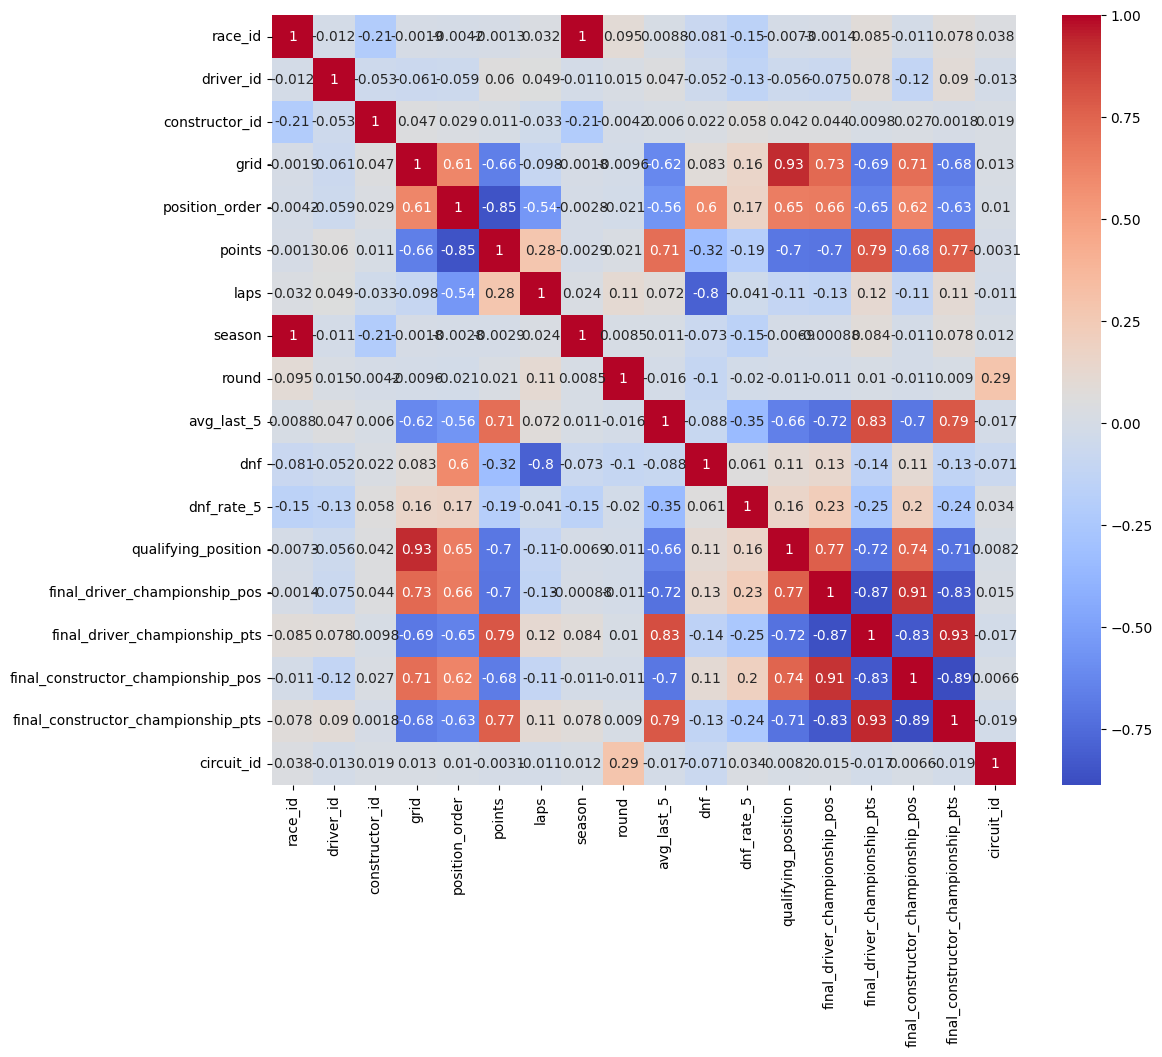

In [66]:
final_dataset= final_dataset.rename(columns={'position_order': 'position'})

#Heatmap of correlations to see similar variables and potential multicollinearity issues
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [91]:
final_dataset['best_10']= final_dataset['position']<=10
final_dataset.head()

,race_id,driver_id,constructor_id,grid,position,points,laps,season,round,avg_last_5,dnf,dnf_rate_5,qualifying_position,final_driver_championship_pos,final_driver_championship_pts,final_constructor_championship_pos,final_constructor_championship_pts,circuit_id,best_10
0,21,0,16,13,14,0,57,2019,1,5.194598,0,0.185685,13.0,8.0,92.0,6,85.0,0,False
1,22,0,16,12,9,2,57,2019,2,0.000000,0,0.000000,12.0,8.0,92.0,6,85.0,1,True
2,23,0,16,0,10,1,55,2019,3,1.000000,0,0.000000,19.0,8.0,92.0,6,85.0,12,True
3,24,0,16,11,11,0,50,2019,4,1.000000,0,0.000000,12.0,8.0,92.0,6,85.0,2,False
4,25,0,16,11,11,0,66,2019,5,0.750000,0,0.000000,12.0,8.0,92.0,6,85.0,3,False


In [90]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import (
    classification_report, accuracy_score,
    average_precision_score,
    mean_absolute_error, mean_squared_error
)

In [96]:
X = final_dataset.drop(columns=[
    'best_10',
    'position', 
    'points', 
    'laps',
    'final_driver_championship_pos',
    'final_driver_championship_pts',
    'final_constructor_championship_pos',
    'final_constructor_championship_pts',
    'dnf'
])
y = final_dataset['best_10']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=406962, stratify=y)
X_train

,race_id,driver_id,constructor_id,grid,season,round,avg_last_5,dnf_rate_5,qualifying_position,circuit_id
632,31,33,9,7,2021,1,7.6,0.000000,7.0,1
128,41,5,0,12,2023,1,5.6,0.200000,12.0,1
156,44,8,1,18,2023,4,0.0,0.333333,20.0,2
917,32,41,4,11,2021,2,1.8,0.000000,11.0,5
399,16,20,6,5,2018,1,0.8,0.400000,6.0,0
...,...,...,...,...,...,...,...,...,...,...
896,11,41,16,8,2017,1,2.4,0.200000,8.0,0
1000,54,45,3,20,2025,3,3.6,0.000000,20.0,15
249,11,13,6,6,2017,1,5.2,0.000000,6.0,0
37,11,1,9,12,2017,1,1.6,0.400000,13.0,0


In [97]:
# scale_pos_weight handles the fact that roughly half the grid
# doesn't finish in the top 10 — balances the class weights
class_weight = (y_train == 0).sum() / (y_train == 1).sum()
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'scale_pos_weight': class_weight,
        'eval_metric':      'logloss',
        'random_state':     42,
    }

    model= xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return accuracy_score(y_test, model.predict(X_test))


In [98]:
BASE_FEATURES = [
    'race_id',
    'driver_id',
    'constructor_id',
    'grid',
    'season',
    'round',
    'avg_last_5',
    'dnf_rate_5',
    'qualifying_position',
    'circuit_id'
]


In [99]:
study= optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)
print(f"Best accuracy: {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

best_params = study.best_params
best_params.update({
    'scale_pos_weight': class_weight,
    'eval_metric':      'logloss',
    'random_state':     42,
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train, verbose=False)

y_pred = final_model.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Top 10', 'Top 10']))

importance = pd.Series(final_model.feature_importances_, index=BASE_FEATURES)
print("\nFeature Importances:")
print(importance.sort_values(ascending=False).to_string())

[I 2026-02-26 12:44:44,330] A new study created in memory with name: no-name-e04eb113-11c8-44fa-9a28-37336178046c
Best trial: 2. Best value: 0.795455:   6%|▌         | 3/50 [00:00<00:03, 12.38it/s]

[I 2026-02-26 12:44:44,432] Trial 0 finished with value: 0.7818181818181819 and parameters: {'n_estimators': 189, 'max_depth': 8, 'learning_rate': 0.03600962930660221, 'subsample': 0.6068298340408115, 'colsample_bytree': 0.9801618605441156, 'min_child_weight': 6, 'gamma': 3.594675151308986}. Best is trial 0 with value: 0.7818181818181819.
[I 2026-02-26 12:44:44,526] Trial 1 finished with value: 0.7363636363636363 and parameters: {'n_estimators': 277, 'max_depth': 5, 'learning_rate': 0.06490242163846256, 'subsample': 0.6233811275405088, 'colsample_bytree': 0.6451830488928295, 'min_child_weight': 1, 'gamma': 2.2511954668539995}. Best is trial 0 with value: 0.7818181818181819.
[I 2026-02-26 12:44:44,578] Trial 2 finished with value: 0.7954545454545454 and parameters: {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.013701519991433243, 'subsample': 0.9600314450969095, 'colsample_bytree': 0.7528292931454051, 'min_child_weight': 10, 'gamma': 3.623992117067975}. Best is trial 2 with 

Best trial: 2. Best value: 0.795455:  10%|█         | 5/50 [00:00<00:05,  8.36it/s]

[I 2026-02-26 12:44:44,721] Trial 3 finished with value: 0.7545454545454545 and parameters: {'n_estimators': 313, 'max_depth': 5, 'learning_rate': 0.03069158287092601, 'subsample': 0.7183715893017875, 'colsample_bytree': 0.7226190450227332, 'min_child_weight': 3, 'gamma': 0.9603199916198724}. Best is trial 2 with value: 0.7954545454545454.
[I 2026-02-26 12:44:44,891] Trial 4 finished with value: 0.7863636363636364 and parameters: {'n_estimators': 391, 'max_depth': 5, 'learning_rate': 0.024558173219762905, 'subsample': 0.6383760956805486, 'colsample_bytree': 0.8389522900201305, 'min_child_weight': 2, 'gamma': 3.71861385677187}. Best is trial 2 with value: 0.7954545454545454.


Best trial: 2. Best value: 0.795455:  12%|█▏        | 6/50 [00:00<00:05,  8.62it/s]

...

[I 2026-02-26 12:44:50,195] Trial 44 finished with value: 0.759090909090909 and parameters: {'n_estimators': 503, 'max_depth': 3, 'learning_rate': 0.037726422742797125, 'subsample': 0.696378183498875, 'colsample_bytree': 0.8255425547530041, 'min_child_weight': 10, 'gamma': 2.4123875819242824}. Best is trial 2 with value: 0.7954545454545454.
[I 2026-02-26 12:44:50,321] Trial 45 finished with value: 0.7681818181818182 and parameters: {'n_estimators': 206, 'max_depth': 4, 'learning_rate': 0.01598783566600378, 'subsample': 0.7315716922680656, 'colsample_bytree': 0.7931237271716007, 'min_child_weight': 6, 'gamma': 4.327077217358649}. Best is trial 2 with value: 0.7954545454545454.


Best trial: 2. Best value: 0.795455:  96%|█████████▌| 48/50 [00:06<00:00,  6.03it/s]

[I 2026-02-26 12:44:50,470] Trial 46 finished with value: 0.7681818181818182 and parameters: {'n_estimators': 420, 'max_depth': 5, 'learning_rate': 0.022136118698341502, 'subsample': 0.7205000343490652, 'colsample_bytree': 0.8803913875361782, 'min_child_weight': 9, 'gamma': 3.6360728624027945}. Best is trial 2 with value: 0.7954545454545454.
[I 2026-02-26 12:44:50,660] Trial 47 finished with value: 0.7863636363636364 and parameters: {'n_estimators': 557, 'max_depth': 4, 'learning_rate': 0.01220200438662968, 'subsample': 0.969066484282909, 'colsample_bytree': 0.693658164060468, 'min_child_weight': 8, 'gamma': 3.0735792339830112}. Best is trial 2 with value: 0.7954545454545454.


Best trial: 2. Best value: 0.795455: 100%|██████████| 50/50 [00:06<00:00,  7.46it/s]


[I 2026-02-26 12:44:50,837] Trial 48 finished with value: 0.7863636363636364 and parameters: {'n_estimators': 471, 'max_depth': 4, 'learning_rate': 0.011548272270990907, 'subsample': 0.9745694504717041, 'colsample_bytree': 0.679822119066796, 'min_child_weight': 7, 'gamma': 2.9060348485305125}. Best is trial 2 with value: 0.7954545454545454.
[I 2026-02-26 12:44:51,031] Trial 49 finished with value: 0.7909090909090909 and parameters: {'n_estimators': 553, 'max_depth': 4, 'learning_rate': 0.011962150548761891, 'subsample': 0.9614675734357253, 'colsample_bytree': 0.6913225305499395, 'min_child_weight': 7, 'gamma': 2.9270187629668385}. Best is trial 2 with value: 0.7954545454545454.
Best accuracy: 0.7955
Best params:   {'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.013701519991433243, 'subsample': 0.9600314450969095, 'colsample_bytree': 0.7528292931454051, 'min_child_weight': 10, 'gamma': 3.623992117067975}

Classification Report:
              precision    recall  f1-score   sup

In [100]:
pd.DataFrame({'test':y_test, 'pred':y_pred}).head(20)

,test,pred
484,True,1
222,False,1
402,False,0
863,False,0
824,True,1
690,False,0
539,False,0
64,True,1
63,True,1
165,True,1
